**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
M.C. Joan Manuel Raygoza Romero

## ICD - 5: Limpieza de datos

Sesión 5 del curso. Diapositivas: [icd-05-limpieza.pdf](https://github.com/husseinlopez/icd2026/blob/main/clases/icd-04-limpieza.pdf)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/husseinlopez/icd2026/blob/main/icd-04-limpieza.ipynb)

Este notebook aplica las técnicas principales de la presentación de limpieza de datos. El objetivo es construir un flujo claro y reproducible.

## 1. Bibliotecas

Usaremos `pandas` y `numpy` para manipular los datos, `matplotlib` y `seaborn` para inspección visual, y escaladores de `scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

## 2. Conjunto de datos de ejemplo

Cada fila representa el registro de una persona en una encuesta de salud. El conjunto contiene problemas deliberados:

- números almacenados como texto;
- diferentes representaciones de valores faltantes;
- categorías inconsistentes;
- alturas registradas en metros y centímetros;
- fechas inválidas o ambiguas;
- duplicados;
- valores fuera del dominio esperado;
- observaciones extremas.

In [2]:
datos = {
    "id": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
           111, 112, 113, 114, 115, 116, 117, 118, 109, 120],
    "edad": ["25", "31", "N/A", "45", "38", "-3", "52", "29", "41", "200",
             "33", "27", "", "60", "49", "36", "42", "31", "41", "55"],
    "ciudad": ["Ensenada", "ensenada ", "TIJUANA", "Mexicali", "Ensenada", "Tijuana",
               "mexicali ", "ENSENADA", "Tecate", "Tijuana", "Ensenada", "N/A",
               "Mexicali", "teCAte", "Tijuana ", "Ensenada", "Mexicali", "tijuana",
               "Tecate", "Ensenada"],
    "ingreso_mensual": [18000, 25000, 22000, 40000, np.nan, 21000, 50000, 19500, 23000,
                        1_200_000, 28000, -999, 26000, 55000, 47000, 24000, np.nan, 27000,
                        23000, 52000],
    "altura": [1.68, 172, 1.75, 165, 1.60, 180, 1.70, 158, 1.82, 1.76,
               169, 1.65, 171, 1.73, 160, 1.67, 174, 1.69, 1.82, 166],
    "unidad_altura": ["m", "cm", "m", "cm", "m", "cm", "m", "cm", "m", "m",
                      "cm", "m", "cm", "m", "cm", "m", "cm", "m", "m", "cm"],
    "fecha_registro": ["2026-01-05", "06/01/2026", "2026-01-07", "31/02/2026",
                       "2026-01-09", "10/01/2026", "2026-01-11", "2026-01-12",
                       "13/01/2026", "2026-01-14", "2026-01-15", "16/01/2026",
                       "2026-01-17", "2026-01-18", "19/01/2026", "2026-01-20",
                       "2026-01-21", "22/01/2026", "13/01/2026", "2027-12-01"],
    "satisfaccion": [4, 5, 3, 4, np.nan, 2, 5, 4, 3, 5, 4, 3, np.nan, 5, 4, 3, 4, 5, 3, 4],
    "comentario_opcional": [np.nan, "Bien", np.nan, np.nan, "Regular", np.nan, np.nan,
                            "Bien", np.nan, np.nan, np.nan, "Bien", np.nan, np.nan,
                            "Excelente", np.nan, np.nan, "Bien", np.nan, np.nan]
}

df_raw = pd.DataFrame(datos)
df_raw

,id,edad,ciudad,ingreso_mensual,altura,unidad_altura,fecha_registro,satisfaccion,comentario_opcional
0,101,25,Ensenada,18000.0,1.68,m,2026-01-05,4.0,NaN
1,102,31,ensenada,25000.0,172.00,cm,06/01/2026,5.0,Bien
2,103,N/A,TIJUANA,22000.0,1.75,m,2026-01-07,3.0,NaN
3,104,45,Mexicali,40000.0,165.00,cm,31/02/2026,4.0,NaN
4,105,38,Ensenada,NaN,1.60,m,2026-01-09,NaN,Regular
5,106,-3,Tijuana,21000.0,180.00,cm,10/01/2026,2.0,NaN
6,107,52,mexicali,50000.0,1.70,m,2026-01-11,5.0,NaN
7,108,29,ENSENADA,19500.0,158.00,cm,2026-01-12,4.0,Bien
8,109,41,Tecate,23000.0,1.82,m,13/01/2026,3.0,NaN
9,110,200,Tijuana,1200000.0,1.76,m,2026-01-14,5.0,NaN


## 3. Diccionario de datos y unidad de análisis

La unidad de análisis es **una persona encuestada en una fecha de registro**.

| Variable | Significado | Tipo esperado | Regla principal |
|---|---|---|---|
| `id` | Identificador de persona | entero/categoría | No negativo |
| `edad` | Edad en años | numérico | Entre 0 y 110 |
| `ciudad` | Ciudad de residencia | categórico | Categoría normalizada |
| `ingreso_mensual` | Ingreso en MXN | numérico | Mayor o igual que 0 |
| `altura` | Altura registrada | numérico | Convertir a metros |
| `fecha_registro` | Fecha de captura | fecha | Válida y no futura |
| `satisfaccion` | Escala de satisfacción | ordinal | Entre 1 y 5 |

## 4. Auditoría inicial

Antes de modificar los datos, revisamos dimensiones, tipos, valores únicos y estadísticas descriptivas.

In [3]:
print("Dimensiones:", df_raw.shape)
display(df_raw.head())

print("\nTipos originales:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nResumen descriptivo:")
display(df_raw.describe(include="all").T)

Dimensiones: (20, 9)


,id,edad,ciudad,ingreso_mensual,altura,unidad_altura,fecha_registro,satisfaccion,comentario_opcional
0,101,25,Ensenada,18000.0,1.68,m,2026-01-05,4.0,NaN
1,102,31,ensenada,25000.0,172.00,cm,06/01/2026,5.0,Bien
2,103,N/A,TIJUANA,22000.0,1.75,m,2026-01-07,3.0,NaN
3,104,45,Mexicali,40000.0,165.00,cm,31/02/2026,4.0,NaN
4,105,38,Ensenada,NaN,1.60,m,2026-01-09,NaN,Regular



Tipos originales:


,dtype
id,int64
edad,object
ciudad,object
ingreso_mensual,float64
altura,float64
unidad_altura,object
fecha_registro,object
satisfaccion,float64
comentario_opcional,object



Resumen descriptivo:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,20.0,NaN,NaN,NaN,110.0,5.572489,101.0,105.75,109.5,114.25,120.0
edad,20,18,31,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ciudad,20,12,Ensenada,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ingreso_mensual,18.0,NaN,NaN,NaN,94416.722222,276283.628155,-999.0,22250.0,25500.0,45250.0,1200000.0
altura,20.0,NaN,NaN,NaN,76.6935,85.162865,1.6,1.6975,1.82,166.75,180.0
unidad_altura,20,2,m,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_registro,20,19,13/01/2026,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
satisfaccion,18.0,NaN,NaN,NaN,3.888889,0.900254,2.0,3.0,4.0,4.75,5.0
comentario_opcional,6,3,Bien,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
for columna in ["edad", "ciudad", "unidad_altura", "satisfaccion"]:
    print(f"\n{columna}:")
    print(df_raw[columna].value_counts(dropna=False))


edad:
edad
31     2
41     2
25     1
N/A    1
38     1
45     1
-3     1
52     1
29     1
200    1
33     1
27     1
       1
60     1
49     1
36     1
42     1
55     1
Name: count, dtype: int64

ciudad:
ciudad
Ensenada     5
Mexicali     3
Tecate       2
Tijuana      2
TIJUANA      1
ensenada     1
mexicali     1
ENSENADA     1
N/A          1
teCAte       1
Tijuana      1
tijuana      1
Name: count, dtype: int64

unidad_altura:
unidad_altura
m     11
cm     9
Name: count, dtype: int64

satisfaccion:
satisfaccion
4.0    7
5.0    5
3.0    5
NaN    2
2.0    1
Name: count, dtype: int64


### Observaciones iniciales

- `ciudad` contiene diferencias de mayúsculas, minúsculas y espacios.
- `ingreso_mensual` utiliza `-999` como código de ausencia.
- `altura` mezcla metros y centímetros.
- `fecha_registro` mezcla formatos y contiene fechas inválidas.
- `comentario_opcional` presenta una proporción alta de faltantes.

## 5. Copia del conjunto de datos

Los datos crudos deben conservarse sin cambios. Todas las operaciones se aplicarán a una copia.

In [5]:
df = df_raw.copy()

## 6. Estandarización de valores faltantes

Primero convertimos las representaciones conocidas de ausencia a `NaN`. Un código solo debe reemplazarse cuando el diccionario o la fuente confirmen que representa un faltante.

In [6]:
codigos_faltantes = ["", "N/A", "NA", "Desconocido", -999]
df = df.replace(codigos_faltantes, np.nan)

faltantes = pd.DataFrame({
    "cantidad": df.isna().sum(),
    "porcentaje": df.isna().mean().mul(100).round(1)
}).sort_values("porcentaje", ascending=False)

faltantes

,cantidad,porcentaje
comentario_opcional,14,70.0
ingreso_mensual,3,15.0
satisfaccion,2,10.0
edad,2,10.0
ciudad,1,5.0
id,0,0.0
altura,0,0.0
fecha_registro,0,0.0
unidad_altura,0,0.0


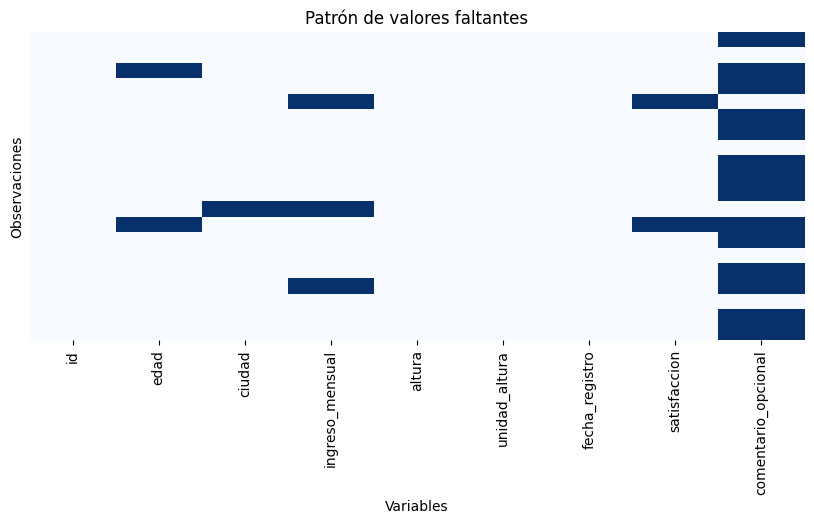

In [7]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="Blues")
plt.title("Patrón de valores faltantes")
plt.xlabel("Variables")
plt.ylabel("Observaciones")
plt.show()

## 7. Conversión y validación de tipos

`errors="coerce"` convierte los valores incompatibles en faltantes. Esto permite identificarlos y tratarlos de forma explícita.

In [8]:
df["edad"] = pd.to_numeric(df["edad"], errors="coerce")
df["satisfaccion"] = pd.to_numeric(df["satisfaccion"], errors="coerce")

# El identificador se conserva como categoría: no representa una cantidad.
df["id"] = df["id"].astype("string")

df.dtypes.to_frame("dtype")

,dtype
id,string[python]
edad,float64
ciudad,object
ingreso_mensual,float64
altura,float64
unidad_altura,object
fecha_registro,object
satisfaccion,float64
comentario_opcional,object


## 8. Normalización de texto

Se eliminan espacios y se unifica el uso de mayúsculas y minúsculas. Después puede aplicarse un vocabulario controlado.

In [9]:
df["ciudad"] = (
    df["ciudad"]
      .str.strip()
      .str.lower()
      .str.title()
)

df["ciudad"].value_counts(dropna=False)

,count
ciudad,
Ensenada,7
Tijuana,5
Mexicali,4
Tecate,3
NaN,1


## 9. Homogeneización de unidades

Convertiremos todas las alturas a metros. La unidad original se conserva hasta verificar la conversión.

In [10]:
df["altura_m"] = np.where(
    df["unidad_altura"].eq("cm"),
    df["altura"] / 100,
    df["altura"]
)

df[["altura", "unidad_altura", "altura_m"]].head(10)

,altura,unidad_altura,altura_m
0,1.68,m,1.68
1,172.00,cm,1.72
2,1.75,m,1.75
3,165.00,cm,1.65
4,1.60,m,1.60
5,180.00,cm,1.80
6,1.70,m,1.70
7,158.00,cm,1.58
8,1.82,m,1.82
9,1.76,m,1.76


In [11]:
print(df["altura_m"].describe())
print("Alturas fuera de 1.30–2.20 m:",
      (~df["altura_m"].between(1.30, 2.20)).sum())

count    20.00000
mean      1.70100
std       0.06897
min       1.58000
25%       1.65750
50%       1.69500
75%       1.74250
max       1.82000
Name: altura_m, dtype: float64
Alturas fuera de 1.30–2.20 m: 0


## 10. Conversión de fechas

Los formatos se mezclaron deliberadamente. Primero probamos el formato ISO y después el formato día/mes/año para los valores pendientes.

In [12]:
fechas_iso = pd.to_datetime(
    df["fecha_registro"],
    format="%Y-%m-%d",
    errors="coerce"
)

fechas_dmy = pd.to_datetime(
    df["fecha_registro"],
    format="%d/%m/%Y",
    errors="coerce"
)

df["fecha_registro_limpia"] = fechas_iso.fillna(fechas_dmy)

df[["fecha_registro", "fecha_registro_limpia"]]

,fecha_registro,fecha_registro_limpia
0,2026-01-05,2026-01-05
1,06/01/2026,2026-01-06
2,2026-01-07,2026-01-07
3,31/02/2026,NaT
4,2026-01-09,2026-01-09
5,10/01/2026,2026-01-10
6,2026-01-11,2026-01-11
7,2026-01-12,2026-01-12
8,13/01/2026,2026-01-13
9,2026-01-14,2026-01-14


## 11. Reglas de validez

Las reglas del dominio permiten localizar valores imposibles o sospechosos. Primero se marcan; no se eliminan automáticamente.

In [13]:
fecha_maxima = pd.Timestamp("2026-12-31")

reglas = pd.DataFrame({
    "edad_valida": df["edad"].between(0, 110) | df["edad"].isna(),
    "ingreso_valido": df["ingreso_mensual"].ge(0) | df["ingreso_mensual"].isna(),
    "altura_valida": df["altura_m"].between(1.30, 2.20) | df["altura_m"].isna(),
    "satisfaccion_valida": df["satisfaccion"].between(1, 5) | df["satisfaccion"].isna(),
    "fecha_valida": df["fecha_registro_limpia"].le(fecha_maxima) & df["fecha_registro_limpia"].notna()
})

display(reglas.sum().to_frame("observaciones_validas"))
display(df.loc[~reglas.all(axis=1)])

,observaciones_validas
edad_valida,18
ingreso_valido,20
altura_valida,20
satisfaccion_valida,20
fecha_valida,18


,id,edad,ciudad,ingreso_mensual,altura,unidad_altura,fecha_registro,satisfaccion,comentario_opcional,altura_m,fecha_registro_limpia
3,104,45.0,Mexicali,40000.0,165.00,cm,31/02/2026,4.0,NaN,1.65,NaT
5,106,-3.0,Tijuana,21000.0,180.00,cm,10/01/2026,2.0,NaN,1.80,2026-01-10
9,110,200.0,Tijuana,1200000.0,1.76,m,2026-01-14,5.0,NaN,1.76,2026-01-14
19,120,55.0,Ensenada,52000.0,166.00,cm,2027-12-01,4.0,NaN,1.66,2027-12-01


### Tratamiento de valores imposibles

Las edades de −3 y 200 no son plausibles para este ejercicio. Las convertimos en faltantes para tratarlas posteriormente. La fecha imposible y la fecha futura también se consideran faltantes.

In [14]:
df.loc[~df["edad"].between(0, 110), "edad"] = np.nan

fecha_invalida = (
    df["fecha_registro_limpia"].isna()
    | df["fecha_registro_limpia"].gt(fecha_maxima)
)
df.loc[fecha_invalida, "fecha_registro_limpia"] = pd.NaT

## 12. Duplicados

La definición depende de la unidad de análisis. Revisaremos duplicados exactos y registros repetidos según `id` y fecha.

In [15]:
print("Duplicados exactos:", df.duplicated().sum())

clave = ["id", "fecha_registro"]
duplicados_clave = df.duplicated(subset=clave, keep=False)
display(df.loc[duplicados_clave].sort_values(clave))

Duplicados exactos: 1


,id,edad,ciudad,ingreso_mensual,altura,unidad_altura,fecha_registro,satisfaccion,comentario_opcional,altura_m,fecha_registro_limpia
8,109,41.0,Tecate,23000.0,1.82,m,13/01/2026,3.0,NaN,1.82,2026-01-13
18,109,41.0,Tecate,23000.0,1.82,m,13/01/2026,3.0,NaN,1.82,2026-01-13


In [16]:
# En este ejemplo conservamos la primera aparición de cada combinación id-fecha.
filas_antes = len(df)
df = df.drop_duplicates(subset=clave, keep="first").copy()

print("Filas eliminadas:", filas_antes - len(df))
print("Dimensiones actuales:", df.shape)

Filas eliminadas: 1
Dimensiones actuales: (19, 11)


## 13. Eliminación de una variable con alta ausencia

`comentario_opcional` no es esencial para esta práctica y tiene muchos faltantes. Antes de eliminar una variable real también se debe valorar su relevancia, no solo su porcentaje de ausencia.

In [17]:
porcentaje_comentarios = df["comentario_opcional"].isna().mean() * 100
print(f"Faltantes en comentario_opcional: {porcentaje_comentarios:.1f}%")

df = df.drop(columns="comentario_opcional")

Faltantes en comentario_opcional: 68.4%


## 14. Imputación simple

Aplicaremos:

- **mediana** para `edad` e `ingreso_mensual`, por su mayor resistencia a valores extremos;
- **moda** para `ciudad`;
- **mediana** para `satisfaccion`.

La imputación modifica la distribución. Por eso crearemos indicadores que permitan reconocer qué valores fueron imputados.

In [18]:
columnas_imputar = ["edad", "ingreso_mensual", "ciudad", "satisfaccion"]

for columna in columnas_imputar:
    df[f"{columna}_era_faltante"] = df[columna].isna().astype(int)

df["edad"] = df["edad"].fillna(df["edad"].median())
df["ingreso_mensual"] = df["ingreso_mensual"].fillna(df["ingreso_mensual"].median())
df["ciudad"] = df["ciudad"].fillna(df["ciudad"].mode().iloc[0])
df["satisfaccion"] = df["satisfaccion"].fillna(df["satisfaccion"].median())

df[columnas_imputar].isna().sum()

,0
edad,0
ingreso_mensual,0
ciudad,0
satisfaccion,0


## 15. Interpolación en una serie temporal

La interpolación requiere un orden con significado. Usaremos una serie independiente de temperatura diaria para no interpolar filas de personas, donde el orden no tiene interpretación.

In [19]:
serie_sensor = pd.DataFrame({
    "fecha": pd.date_range("2026-02-01", periods=10, freq="D"),
    "temperatura": [19.2, 19.5, np.nan, 20.1, 20.4,
                    np.nan, np.nan, 21.0, 20.8, 20.6]
})

serie_sensor["temperatura_interpolada"] = (
    serie_sensor["temperatura"].interpolate(method="linear")
)

serie_sensor

,fecha,temperatura,temperatura_interpolada
0,2026-02-01,19.2,19.2
1,2026-02-02,19.5,19.5
2,2026-02-03,NaN,19.8
3,2026-02-04,20.1,20.1
4,2026-02-05,20.4,20.4
5,2026-02-06,NaN,20.6
6,2026-02-07,NaN,20.8
7,2026-02-08,21.0,21.0
8,2026-02-09,20.8,20.8
9,2026-02-10,20.6,20.6


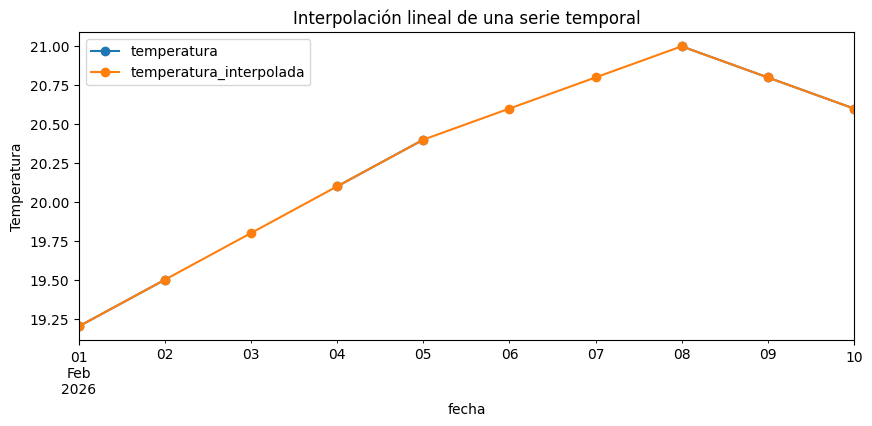

In [20]:
ax = serie_sensor.plot(
    x="fecha",
    y=["temperatura", "temperatura_interpolada"],
    marker="o",
    figsize=(10, 4)
)
ax.set_title("Interpolación lineal de una serie temporal")
ax.set_ylabel("Temperatura")
plt.show()

## 16. Detección de atípicos univariantes con IQR

Para una variable (x):

$$
IQR = Q_3-Q_1
$$

$$
L_i=Q_1-1.5IQR, \qquad L_s=Q_3+1.5IQR
$$

Los valores fuera de los límites son candidatos a revisión, no errores confirmados.

In [21]:
def limites_iqr(serie, factor=1.5):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr

lim_inf, lim_sup = limites_iqr(df["ingreso_mensual"])
mascara_iqr = ~df["ingreso_mensual"].between(lim_inf, lim_sup)

print(f"Límite inferior: {lim_inf:,.2f}")
print(f"Límite superior: {lim_sup:,.2f}")
display(df.loc[mascara_iqr, ["id", "ingreso_mensual"]])

Límite inferior: -6,500.00
Límite superior: 73,500.00


,id,ingreso_mensual
9,110,1200000.0


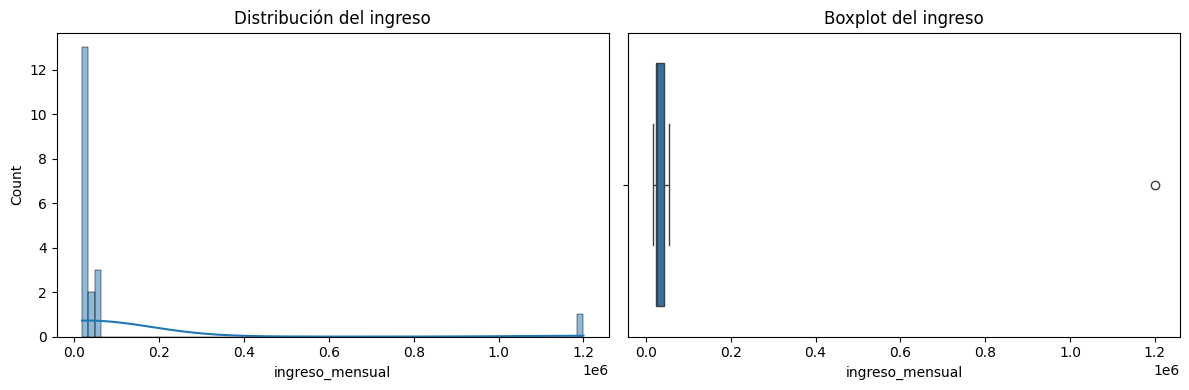

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["ingreso_mensual"], kde=True, ax=axes[0])
axes[0].set_title("Distribución del ingreso")
sns.boxplot(x=df["ingreso_mensual"], ax=axes[1])
axes[1].set_title("Boxplot del ingreso")
plt.tight_layout()
plt.show()

## 17. Tratamiento de un valor extremo

El ingreso de 1,200,000 MXN podría ser válido. Para este ejercicio no eliminaremos la fila. Crearemos una versión limitada mediante *winsorización* usando los límites del IQR y conservaremos la variable original.

In [24]:
df["ingreso_winsorizado"] = df["ingreso_mensual"].clip(
    lower=lim_inf,
    upper=lim_sup
)

df.loc[mascara_iqr, ["ingreso_mensual", "ingreso_winsorizado"]]

,ingreso_mensual,ingreso_winsorizado
9,1200000.0,73500.0


## 18. Transformación logarítmica

La transformación

$$
x'=\log(1+x)
$$

comprime la cola derecha y es válida cuando $$x\geq 0$$
No convierte automáticamente la distribución en normal.

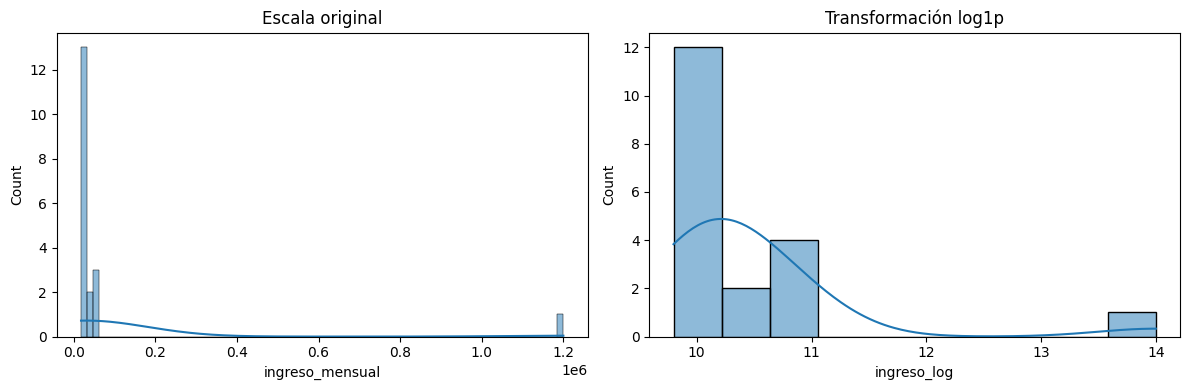

In [25]:
df["ingreso_log"] = np.log1p(df["ingreso_mensual"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["ingreso_mensual"], kde=True, ax=axes[0])
axes[0].set_title("Escala original")
sns.histplot(df["ingreso_log"], kde=True, ax=axes[1])
axes[1].set_title("Transformación log1p")
plt.tight_layout()
plt.show()

## 19. Escalado de variables

Compararemos tres métodos sobre `edad`, `altura_m` e `ingreso_mensual`:

- `StandardScaler`: media aproximada 0 y desviación estándar aproximada 1;
- `MinMaxScaler`: lleva los valores al intervalo ([0,1]);
- `RobustScaler`: utiliza mediana e IQR y reduce la influencia de extremos.

Los escaladores se ajustan con `fit` y se aplican con `transform`. Aunque aquí no se entrenan modelos, conservamos esa separación como buena práctica.

In [26]:
variables_escalar = ["edad", "altura_m", "ingreso_mensual"]
X_num = df[variables_escalar].copy()

escaladores = {
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler()
}

resultados_escalado = {}

for nombre, escalador in escaladores.items():
    escalador.fit(X_num)
    valores = escalador.transform(X_num)
    resultados_escalado[nombre] = pd.DataFrame(
        valores,
        columns=[f"{col}_{nombre}" for col in variables_escalar],
        index=df.index
    )

display(resultados_escalado["standard"].head())
display(resultados_escalado["minmax"].head())
display(resultados_escalado["robust"].head())

,edad_standard,altura_m_standard,ingreso_mensual_standard
0,-1.539127,-0.233821,-0.285019
1,-0.891671,0.400836,-0.258229
2,-0.136306,0.876829,-0.269710
3,0.619058,-0.709814,-0.200822
4,-0.136306,-1.503135,-0.252488


,edad_minmax,altura_m_minmax,ingreso_mensual_minmax
0,0.000000,0.416667,0.000000
1,0.171429,0.583333,0.005922
2,0.371429,0.708333,0.003384
3,0.571429,0.291667,0.018613
4,0.371429,0.083333,0.007191


,edad_robust,altura_m_robust,ingreso_mensual_robust
0,-1.130435,-0.125,-0.425
1,-0.608696,0.375,-0.075
2,0.000000,0.750,-0.225
3,0.608696,-0.500,0.675
4,0.000000,-1.125,0.000


### Comparación del ingreso escalado

La presencia del ingreso extremo permite observar que `StandardScaler` y `MinMaxScaler` son sensibles a valores extremos. `RobustScaler` usa estadísticas más resistentes, pero no elimina el valor atípico.

In [27]:
comparacion = pd.DataFrame({
    "original": df["ingreso_mensual"],
    "standard": resultados_escalado["standard"]["ingreso_mensual_standard"],
    "minmax": resultados_escalado["minmax"]["ingreso_mensual_minmax"],
    "robust": resultados_escalado["robust"]["ingreso_mensual_robust"]
})

comparacion.sort_values("original", ascending=False).head()

,original,standard,minmax,robust
9,1200000.0,4.238621,1.000000,58.675
13,55000.0,-0.143416,0.031303,1.425
19,52000.0,-0.154897,0.028765,1.275
6,50000.0,-0.162551,0.027073,1.175
14,47000.0,-0.174033,0.024535,1.025


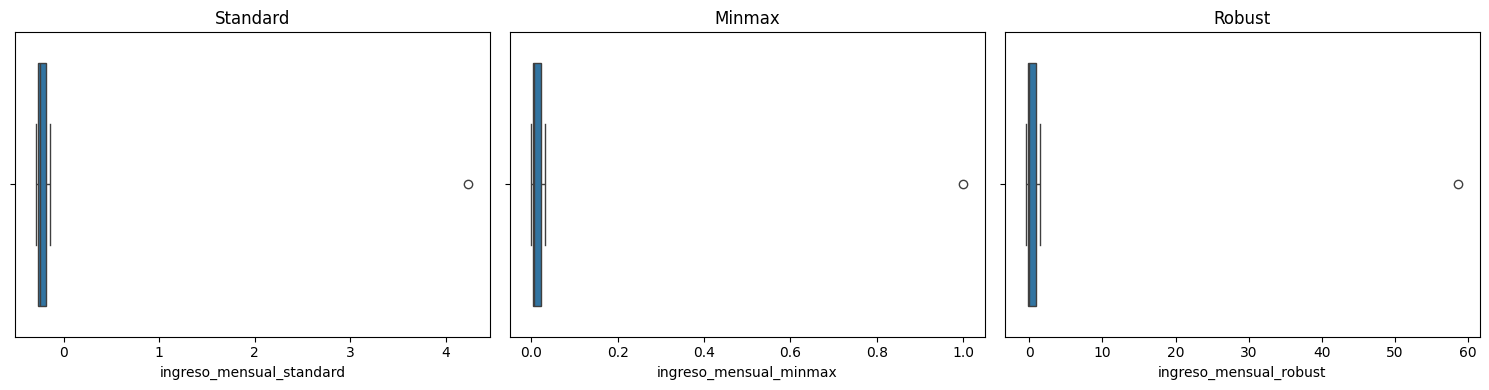

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metodo in zip(axes, ["standard", "minmax", "robust"]):
    columna = f"ingreso_mensual_{metodo}"
    sns.boxplot(x=resultados_escalado[metodo][columna], ax=ax)
    ax.set_title(metodo.capitalize())

plt.tight_layout()
plt.show()

## 20. Construcción del conjunto final

Para una versión limpia seleccionamos:

- las variables corregidas;
- la altura unificada en metros;
- la fecha convertida;
- los indicadores de imputación;
- una versión logarítmica y una versión winsorizada del ingreso.

No es necesario conservar simultáneamente todas las versiones en un análisis real. Aquí se mantienen con fines didácticos.

In [29]:
columnas_finales = [
    "id", "edad", "ciudad", "ingreso_mensual",
    "ingreso_winsorizado", "ingreso_log", "altura_m",
    "fecha_registro_limpia", "satisfaccion",
    "edad_era_faltante", "ingreso_mensual_era_faltante",
    "ciudad_era_faltante", "satisfaccion_era_faltante"
]

df_limpio = df[columnas_finales].copy()
df_limpio.head()

,id,edad,ciudad,ingreso_mensual,ingreso_winsorizado,ingreso_log,altura_m,fecha_registro_limpia,satisfaccion,edad_era_faltante,ingreso_mensual_era_faltante,ciudad_era_faltante,satisfaccion_era_faltante
0,101,25.0,Ensenada,18000.0,18000.0,9.798183,1.68,2026-01-05,4.0,0,0,0,0
1,102,31.0,Ensenada,25000.0,25000.0,10.126671,1.72,2026-01-06,5.0,0,0,0,0
2,103,38.0,Tijuana,22000.0,22000.0,9.998843,1.75,2026-01-07,3.0,1,0,0,0
3,104,45.0,Mexicali,40000.0,40000.0,10.596660,1.65,NaT,4.0,0,0,0,0
4,105,38.0,Ensenada,26500.0,26500.0,10.184938,1.60,2026-01-09,4.0,0,1,0,1


## 21. Validación final

La limpieza termina con una nueva auditoría. Verificamos dimensiones, faltantes, duplicados, tipos y reglas del dominio.

In [31]:
reporte_final = pd.Series({
    "filas_originales": len(df_raw),
    "filas_finales": len(df_limpio),
    "faltantes_finales": int(df_limpio.isna().sum().sum()),
    "duplicados_id_fecha": int(df_limpio.duplicated(
        subset=["id", "fecha_registro_limpia"]
    ).sum()),
    "edades_invalidas": int((~df_limpio["edad"].between(0, 110)).sum()),
    "alturas_invalidas": int((~df_limpio["altura_m"].between(1.30, 2.20)).sum()),
    "satisfaccion_invalida": int((~df_limpio["satisfaccion"].between(1, 5)).sum())
})

reporte_final.to_frame("resultado")

,resultado
filas_originales,20
filas_finales,19
faltantes_finales,2
duplicados_id_fecha,0
edades_invalidas,0
alturas_invalidas,0
satisfaccion_invalida,0


In [32]:
comparacion_estadistica = pd.concat(
    {
        "original": pd.to_numeric(df_raw["ingreso_mensual"], errors="coerce").replace(-999, np.nan).describe(),
        "limpio": df_limpio["ingreso_mensual"].describe(),
        "winsorizado": df_limpio["ingreso_winsorizado"].describe()
    },
    axis=1
)

comparacion_estadistica

,original,limpio,winsorizado
count,1.700000e+01,1.900000e+01,19.000000
mean,1.000294e+05,9.247368e+04,33184.210526
std,2.837269e+05,2.684541e+05,15225.353970
min,1.800000e+04,1.800000e+04,18000.000000
25%,2.300000e+04,2.350000e+04,23500.000000
50%,2.600000e+04,2.650000e+04,26500.000000
75%,4.700000e+04,4.350000e+04,43500.000000
max,1.200000e+06,1.200000e+06,73500.000000


## 22. Registro de decisiones

| Problema | Tratamiento aplicado | Riesgo o limitación |
|---|---|---|
| Códigos de ausencia | Conversión a `NaN` | Requiere confirmar el significado del código |
| Edad imposible | Conversión a faltante y mediana | Reduce variabilidad |
| Ciudad inconsistente | Normalización de texto y moda | La moda aumenta la categoría dominante |
| Alturas con unidades mixtas | Conversión a metros | Depende de que la unidad original sea correcta |
| Fechas inválidas | Conversión a `NaT` | Se pierde la fecha original en el análisis final |
| Duplicado por clave | Conservación de la primera fila | La regla podría no ser adecuada en otro contexto |
| Ingreso extremo | Se conserva y se crea versión winsorizada | La winsorización reduce la magnitud del evento |
| Variable con alta ausencia | Eliminación | Podría contener información útil |

## 23. Ejercicios

1. Cambia la imputación de `edad` de mediana a media. Compara las estadísticas resultantes.
2. Repite la detección de atípicos usando factores IQR de 1.5 y 3.0.
3. Conserva la fecha futura y crea una variable booleana que la identifique.

## Conclusiones

- Los valores faltantes, duplicados y atípicos necesitan una interpretación contextual.
- Las transformaciones pueden modificar la forma de una distribución.
- Los escalados cambian la magnitud y responden de manera diferente a valores extremos.
- Los datos crudos deben conservarse y cada decisión debe documentarse.
- La validación final permite verificar que el proceso produjo el resultado esperado.

### Declaración de uso de IA generativa

Este notebook fue elaborado con apoyo de ChatGPT 5.6 (OpenAI) para estructurar el contenido a partir de las diapositivas de la sesión y redactar el texto explicativo. El diseño pedagógico, la selección de temas y la revisión final son responsabilidad del titular del curso.